# 02. 돌발 유형별 / 시간대별 / 계절별 패턴 분석
돌발상세구분을 중심으로 요일·시간대·계절에 따른 발생 패턴을 분석한다.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.load_data import load
from src.plot_config import set_korean_style

set_korean_style()
FIG_DIR = pathlib.Path('../outputs/figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)

df = load()
df.shape

(623188, 19)

## 2.1 돌발상세구분 Top 10 빈도

/tmp/ipykernel_572/1825874174.py:8: UserWarning: Glyph 51089 (\N{HANGUL SYLLABLE JAG}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_572/1825874174.py:8: UserWarning: Glyph 50629 (\N{HANGUL SYLLABLE EOB}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_572/1825874174.py:8: UserWarning: Glyph 49324 (\N{HANGUL SYLLABLE SA}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_572/1825874174.py:8: UserWarning: Glyph 44256 (\N{HANGUL SYLLABLE GO}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_572/1825874174.py:8: UserWarning: Glyph 52264 (\N{HANGUL SYLLABLE CA}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_572/1825874174.py:8: UserWarning: Glyph 47049 (\N{HANGUL SYLLABLE RYANG}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_572/1825874174.py:8: UserWarning: Glyph 51613 (\N{HANGUL SYLLABLE JEUNG}) missing from font(s) Liberation Sans

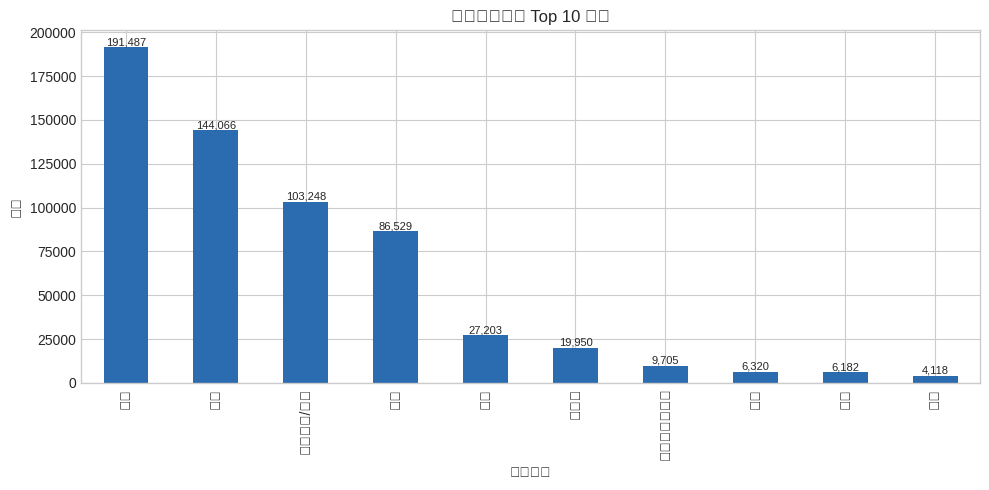

In [2]:
top10 = df['돌발상세구분'].value_counts().head(10)
fig, ax = plt.subplots(figsize=(10,5))
top10.plot(kind='bar', ax=ax, color='#2b6cb0')
ax.set_title('돌발상세구분 Top 10 빈도')
ax.set_xlabel('카테고리'); ax.set_ylabel('건수')
for i, v in enumerate(top10.values):
    ax.text(i, v, f'{v:,}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / '01_top10_type.png', dpi=150)
plt.show()

## 2.2 월별 Top 카테고리 트렌드

/tmp/ipykernel_572/2659920995.py:14: UserWarning: Glyph 50900 (\N{HANGUL SYLLABLE WEOL}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_572/2659920995.py:14: UserWarning: Glyph 44148 (\N{HANGUL SYLLABLE GEON}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_572/2659920995.py:14: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_572/2659920995.py:14: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_572/2659920995.py:14: UserWarning: Glyph 46028 (\N{HANGUL SYLLABLE DOL}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_572/2659920995.py:14: UserWarning: Glyph 48156 (\N{HANGUL SYLLABLE BAL}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_572/2659920995.py:14: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) Liber

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 44053 (\N{HANGUL SYLLABLE GANG}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 50864 (\N{HANGUL SYLLABLE U}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 51109 (\N{HANGUL SYLLABLE JANG}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 49324 (\N{HANGUL SYLLABLE SA}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 51089 (\N{HANGUL SYLLABLE JAG}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(by

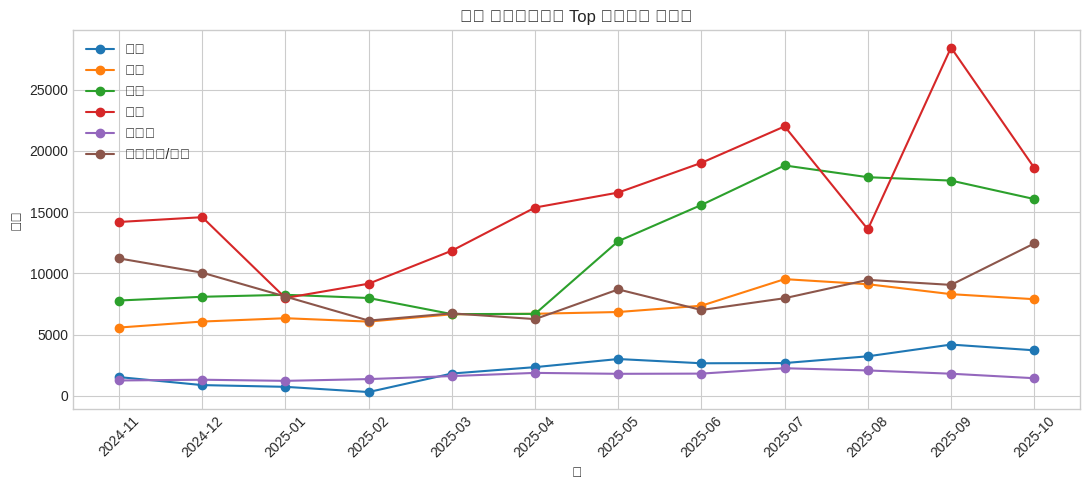

In [3]:
top_cats = ['사고','작업','고장','차량증가/정체','강우','장애물']
monthly = (df[df['돌발상세구분'].isin(top_cats)]
           .groupby([df['돌발일시'].dt.to_period('M'), '돌발상세구분'])
           .size().unstack(fill_value=0))
monthly.index = monthly.index.astype(str)

fig, ax = plt.subplots(figsize=(11,5))
for col in monthly.columns:
    ax.plot(monthly.index, monthly[col], marker='o', label=col)
ax.set_title('월별 돌발상세구분 Top 카테고리 트렌드')
ax.set_xlabel('월'); ax.set_ylabel('건수')
plt.xticks(rotation=45)
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / '02_monthly_trend.png', dpi=150)
plt.show()

## 2.3 평일 vs 주말 전체 발생량

/tmp/ipykernel_572/189164612.py:7: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_572/189164612.py:7: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_572/189164612.py:7: UserWarning: Glyph 51452 (\N{HANGUL SYLLABLE JU}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_572/189164612.py:7: UserWarning: Glyph 47568 (\N{HANGUL SYLLABLE MAL}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_572/189164612.py:7: UserWarning: Glyph 44277 (\N{HANGUL SYLLABLE GONG}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_572/189164612.py:7: UserWarning: Glyph 55092 (\N{HANGUL SYLLABLE HYU}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_572/189164612.py:7: UserWarning: Glyph 50836 (\N{HANGUL SYLLABLE YO}) missing from font(s) Liberation Sans.
  plt

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 51452 (\N{HANGUL SYLLABLE JU}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 47568 (\N{HANGUL SYLLABLE MAL}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure

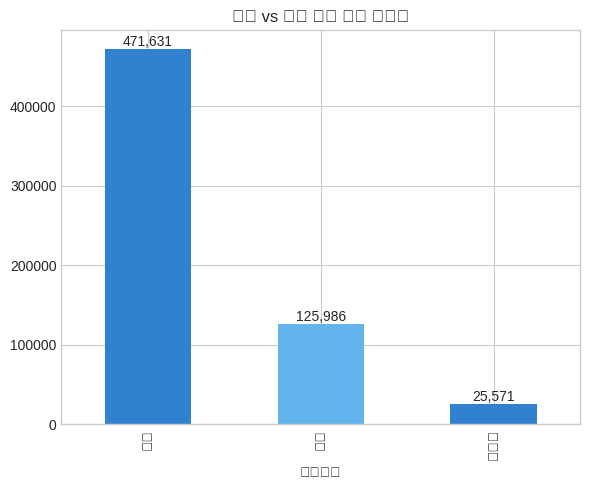

In [4]:
weekday_cnt = df['요일구분'].value_counts()
fig, ax = plt.subplots(figsize=(6,5))
weekday_cnt.plot(kind='bar', ax=ax, color=['#3182ce','#63b3ed'])
ax.set_title('평일 vs 주말 전체 돌발 발생량')
for i, v in enumerate(weekday_cnt.values):
    ax.text(i, v, f'{v:,}', ha='center', va='bottom')
plt.tight_layout()
plt.savefig(FIG_DIR / '03_weekday_weekend.png', dpi=150)
plt.show()

## 2.4 돌발상세구분 x 요일 히트맵

/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 44053 (\N{HANGUL SYLLABLE GANG}) missing from font(s) Liberation Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 50864 (\N{HANGUL SYLLABLE U}) missing from font(s) Liberation Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 44256 (\N{HANGUL SYLLABLE GO}) missing from font(s) Liberation Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 51109 (\N{HANGUL SYLLABLE JANG}) missing from font(s) Liberation Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 49324 (\N{HANGUL SYLLABLE SA}) missing from font(s) Liberation Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 51089 (\N{HANGUL SYLLABLE JAG}) missing from font(s) Liberation Sans.
  

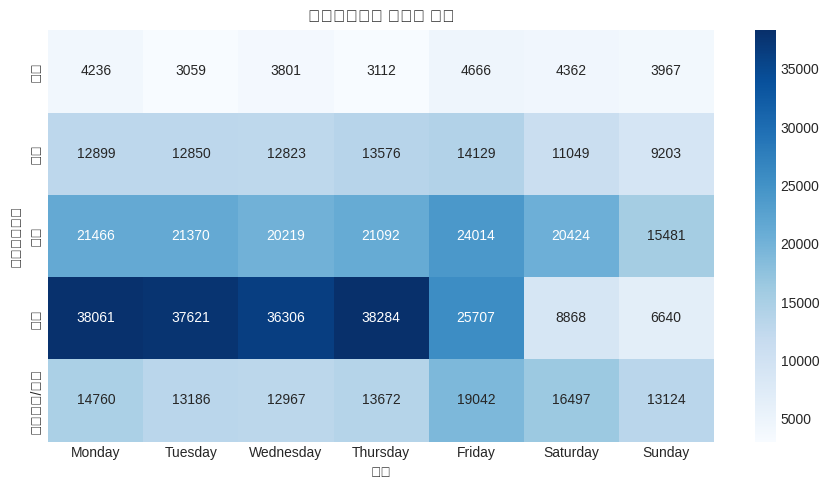

In [5]:
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
top5 = df['돌발상세구분'].value_counts().head(5).index
pivot = (df[df['돌발상세구분'].isin(top5)]
         .groupby(['돌발상세구분','요일']).size().unstack(fill_value=0)[day_order])

fig, ax = plt.subplots(figsize=(9,5))
sns.heatmap(pivot, annot=True, fmt='d', cmap='Blues', ax=ax)
ax.set_title('돌발상세구분 요일별 건수')
plt.tight_layout()
plt.savefig(FIG_DIR / '04_weekday_heatmap.png', dpi=150)
plt.show()

## 2.5 시간대별 돌발상세구분 (평일 vs 주말)

/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 44053 (\N{HANGUL SYLLABLE GANG}) missing from font(s) Liberation Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 50864 (\N{HANGUL SYLLABLE U}) missing from font(s) Liberation Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 44256 (\N{HANGUL SYLLABLE GO}) missing from font(s) Liberation Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 51109 (\N{HANGUL SYLLABLE JANG}) missing from font(s) Liberation Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 49324 (\N{HANGUL SYLLABLE SA}) missing from font(s) Liberation Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 51089 (\N{HANGUL SYLLABLE JAG}) missing from font(s) Liberation Sans.
  

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 46028 (\N{HANGUL SYLLABLE DOL}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(

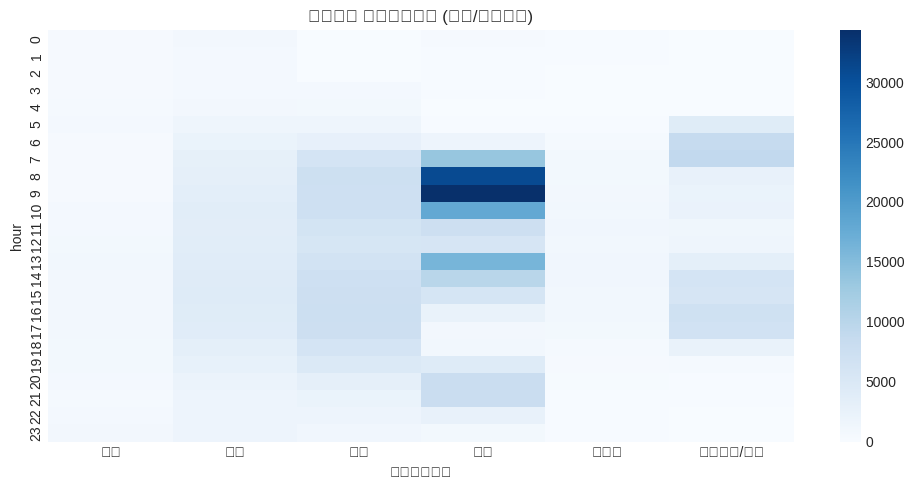

/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 44053 (\N{HANGUL SYLLABLE GANG}) missing from font(s) Liberation Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 50864 (\N{HANGUL SYLLABLE U}) missing from font(s) Liberation Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 44256 (\N{HANGUL SYLLABLE GO}) missing from font(s) Liberation Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 51109 (\N{HANGUL SYLLABLE JANG}) missing from font(s) Liberation Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 49324 (\N{HANGUL SYLLABLE SA}) missing from font(s) Liberation Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 51089 (\N{HANGUL SYLLABLE JAG}) missing from font(s) Liberation Sans.
  

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 46028 (\N{HANGUL SYLLABLE DOL}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(

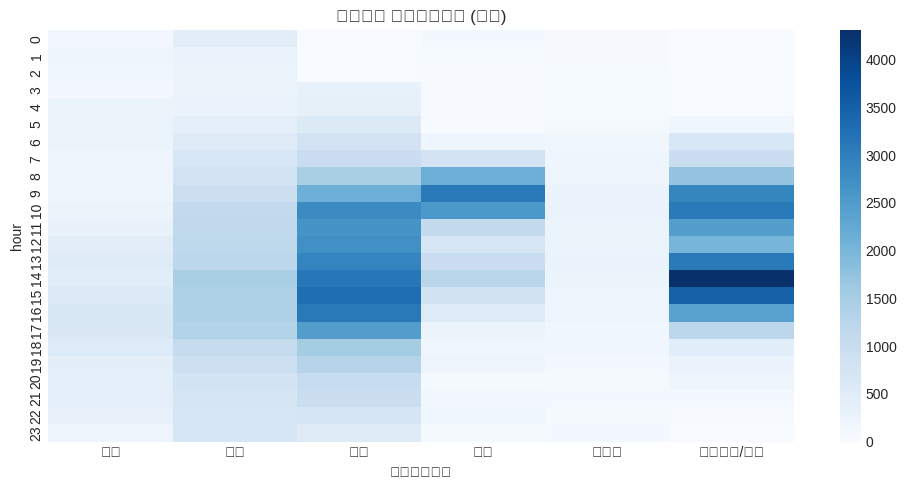

In [6]:
for label, sub in [('평일/휴일제외', df[df['요일구분']=='평일']), ('주말', df[df['요일구분']=='주말'])]:
    top6 = sub['돌발상세구분'].value_counts().head(6).index
    pv = sub[sub['돌발상세구분'].isin(top6)].groupby(['hour','돌발상세구분']).size().unstack(fill_value=0)
    fig, ax = plt.subplots(figsize=(10,5))
    sns.heatmap(pv, cmap='Blues', ax=ax)
    ax.set_title(f'시간대별 돌발상세구분 ({label})')
    plt.tight_layout()
    fname = '05a_hourly_weekday.png' if label.startswith('평일') else '05b_hourly_weekend.png'
    plt.savefig(FIG_DIR / fname, dpi=150)
    plt.show()

## 2.6 계절별 돌발 건수 및 비율

,건수,비율(%)
season,,
봄,137185,22.01
여름,182764,29.33
가을,183921,29.51
겨울,119318,19.15


/tmp/ipykernel_572/1309898060.py:9: UserWarning: Glyph 48388 (\N{HANGUL SYLLABLE BOM}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_572/1309898060.py:9: UserWarning: Glyph 50668 (\N{HANGUL SYLLABLE YEO}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_572/1309898060.py:9: UserWarning: Glyph 47492 (\N{HANGUL SYLLABLE REUM}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_572/1309898060.py:9: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_572/1309898060.py:9: UserWarning: Glyph 51012 (\N{HANGUL SYLLABLE EUL}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_572/1309898060.py:9: UserWarning: Glyph 44200 (\N{HANGUL SYLLABLE GYEO}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_572/1309898060.py:9: UserWarning: Glyph 50872 (\N{HANGUL SYLLABLE UL}) missing from font(s) Liberation Sans.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 48388 (\N{HANGUL SYLLABLE BOM}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 50668 (\N{HANGUL SYLLABLE YEO}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 47492 (\N{HANGUL SYLLABLE REUM}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 51012 (\N{HANGUL SYLLABLE EUL}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(b

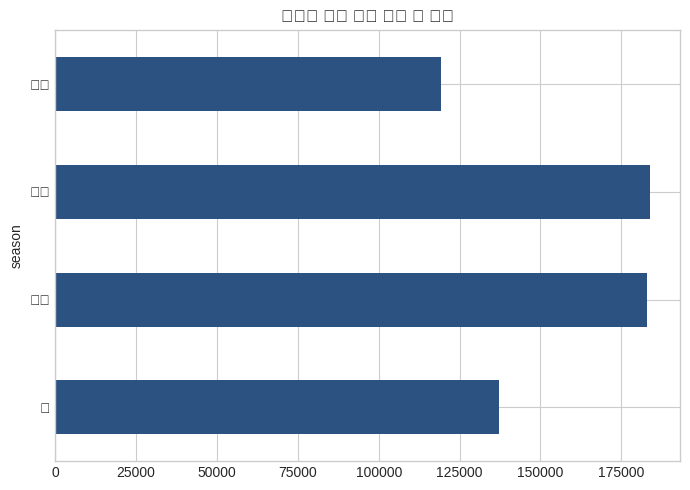

In [7]:
season_order = ['봄','여름','가을','겨울']
season_cnt = df['season'].value_counts().reindex(season_order)
season_pct = (season_cnt / season_cnt.sum() * 100).round(2)
display(pd.DataFrame({'건수': season_cnt, '비율(%)': season_pct}))

fig, ax = plt.subplots(figsize=(7,5))
season_cnt.plot(kind='barh', ax=ax, color='#2c5282')
ax.set_title('계절별 전체 돌발 건수 및 비율')
plt.tight_layout()
plt.savefig(FIG_DIR / '06_seasonal.png', dpi=150)
plt.show()

## 2.7 계절별 교통사고 비율

In [8]:
accident = df[df['돌발상세구분']=='사고']
season_accident = accident['season'].value_counts().reindex(season_order)
season_accident_ratio = (season_accident / season_cnt * 100).round(1)
display(pd.DataFrame({'사고건수': season_accident, '전체대비비율(%)': season_accident_ratio}))

,사고건수,전체대비비율(%)
season,,
봄,26014,19.0
여름,52262,28.6
가을,41442,22.5
겨울,24348,20.4
